# **Multivariate Regression**
### House price prediction problem :

## Goal:
Predict house price using:

- Size (sq ft)

- Number of bedrooms

- Age of house

## STEP 1: CREATING SYNTHETIC DATA 


In [2]:
import pandas as pd
import numpy as np


#### → Creating synthetic data using numpy's np.random.randint() function that generates random integers.

> Basic syntax: **np. random. randint(low, high, size)**
> - low : starting number (included)
> - high : ending number (not included)
> - size : how many numbers you want



#### 1. Why we're using it here?

 We're creating synthetic data for experimentation.

**randint()** helps to:

- Simulate real-world values

- create datasets quickly

- Test  models



#### 2. Controlling Randomness using **np.random.seed()**

Before generating random data, we use: **np.random.seed(42)**

#### 3. Why?

- It ensures **reproducibility**  
- The same random numbers are generated every time the code runs  
- Helps in debugging and comparing models  

#### 4. Important:

- Same seed → same results  
- Different seed → different results  
- No seed → results change every run  

> Note: The number `42` is just a commonly used value. Any number can be used as a seed.


In [5]:
np.random.seed(42)

#Features/predictors
size = np.random.randint(500, 3000, 100) #in sq ft
bedrooms = np.random.randint(1, 5, 100)
age = np.random.randint(0, 30, 100)


- In real life, we usually **do not know the exact relationship** between features (X) and target (y).  
- Machine learning models try to **discover this hidden relationship** from data.

 **Why we write a formula in this experiment?**

> Since we are **learning and experimenting**, we create a synthetic dataset where we **define the relationship ourselves**:
``` python
price = (
    3000 * size +       # bigger houses cost more
    50000 * bedrooms -  # more bedrooms increase price
    2000 * age +        # older houses are slightly cheaper
    np.random.normal(0, 50000, 100)  # random noise
)
```

**Purpose:**

- Provides a controlled environment to test and understand regression

- Lets us check if the model learns the correct coefficients

- Makes debugging easier before moving on to real datasets

- In real-world projects, we won’t write the formula; the models learn it directly from data.

-  Here, we write it just for learning and experimentation.

In [6]:
# Target (price)
price = (
    3000 * size +
    50000 * bedrooms -
    2000 * age +
    np.random.normal(0, 50000, 100)  # noise
)

# DataFrame
df = pd.DataFrame({
    "size": size,
    "bedrooms": bedrooms,
    "age": age,
    "price": price
})

print(df.head())

   size  bedrooms  age         price
0  1360         2   18  4.058474e+06
1  1794         1    9  5.419949e+06
2  1630         4   11  5.118024e+06
3  1595         3   23  4.896621e+06
4  2138         3   14  6.505930e+06


## STEP 2: TRAIN A MULTIVARIATE REGRESSION MODEL


We train a **linear regression model** to predict house prices using multiple features: **size, number of bedrooms, and age**.

**Explanation** for below code:

- X →  input features (size, bedrooms, age)
- y → target variable (price)
- train_test_split → splits data into 80% training and 20% testing
- LinearRegression() → creates the regression model
- model.fit() → trains the model on the training data
- model.intercept_ → the y-intercept (w0)
- model.coef_ → coefficients (w1, w2, w3) for each feature

The model learns how much each feature affects the house price. For example, a larger coefficient means that feature has a stronger effect on price.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features and target
X = df[["size", "bedrooms", "age"]]
y = df["price"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -15878.019506086595
Coefficients: [ 3001.4390311  55046.33129215 -2225.44480644]


## STEP 4: PREDICT ON TEST DATA

In [17]:
y_pred = model.predict(X_test)

## STEP 5: EVALUATE MODEL

- **mean_squared_error** → computes how far predictions are from actual values (squared)

- **r2_score** → computes how well our model explains the variance in the data

- **numpy** → used here for square root to get RMSE

### 1. Predicting on test data

``` python y_pred = model.predict(X_test)```

- X_test → the features from  test dataset

- y_pred → predicted prices from the model

- Purpose:To check how our model performs on data it hasn’t seen yet

### 2. Calculate evaluation metrics

```python   mse = mean_squared_error(y_test, y_pred)```
``` python r2 = r2_score(y_test, y_pred)```

- mse (Mean Squared Error): Squared difference between actual and predicted values

- Large numbers if prices are high, because squared

-r2 : Fraction of variance in y_test explained by model

1 → perfect prediction, 0 → model does no better than mean

4️⃣ Convert MSE → RMSE (real-world error)
rmse = np.sqrt(mse)

RMSE = Root Mean Squared Error

Why? Squared MSE is hard to interpret because it’s in “squared units”

RMSE brings it back to the same units as price, so you can say:

“On average, my predictions are off by ₹60,000”

5️⃣ Compare error to real-world scale
mean_price = y.mean()
error_percent = (rmse / mean_price) * 100

mean_price → average house price in your dataset

error_percent → RMSE as a percentage of average price

Purpose: helps you answer:

“Is the error big or small in real life?”

Example:

RMSE = 60,000

Average price = 600,000

Error % = 10% → relatively small, model is good



In [23]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 1: Predict on test data
y_pred = model.predict(X_test)

# Step 2: Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Step 3: Convert MSE to RMSE (real-world error)
rmse = np.sqrt(mse)

# Step 4: Compare with real-world scale
mean_price = y.mean()
error_percent = (rmse / mean_price) * 100

# Step 5: Print results
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Average Price:", mean_price)
print("Error %:", error_percent)

MSE: 3558713764.673587
RMSE: 59654.95591041524
R2 Score: 0.998504625764887
Average Price: 5500064.755487128
Error %: 1.0846227919571418


## STEP 6: PREDICT ON NEW DATA

In [19]:
new_data = pd.DataFrame({
    "size": [1200, 2500, 1800],
    "bedrooms": [2, 4, 3],
    "age": [10, 5, 8]
})

predictions = model.predict(new_data)

print("\nNew Predictions:")
for i, price in enumerate(predictions):
    print(f"House {i+1}: {price:.2f}")


New Predictions:
House 1: 3673687.03
House 2: 7696777.66
House 3: 5534047.67


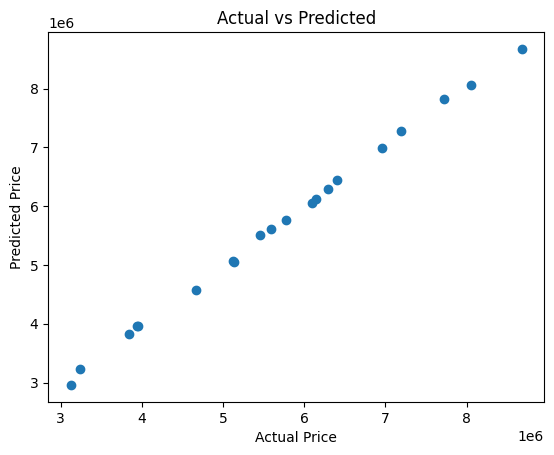

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()